# EXPLORATORY DATA ANALYSIS

**1.	Data Cleaning and Preparation:**

In [ ]:
##importing packages
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
##Loading dataset
df=pd.read_csv('Cardiotocographic.csv')

In [ ]:
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [ ]:
##Checking Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [ ]:
##Checking Missing Values
df.isnull().sum()

,0
LB,21
AC,20
FM,0
UC,0
DL,0
DS,21
DP,21
ASTV,0
MSTV,0
ALTV,0


In [ ]:
##handling missing values
df.fillna(df.mean(numeric_only=True),inplace=True)

In [ ]:
df.isnull().sum()

,0
LB,0
AC,0
FM,0
UC,0
DL,0
DS,0
DP,0
ASTV,0
MSTV,0
ALTV,0


In [ ]:
##Checking Data Types
print(df.dtypes)

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object


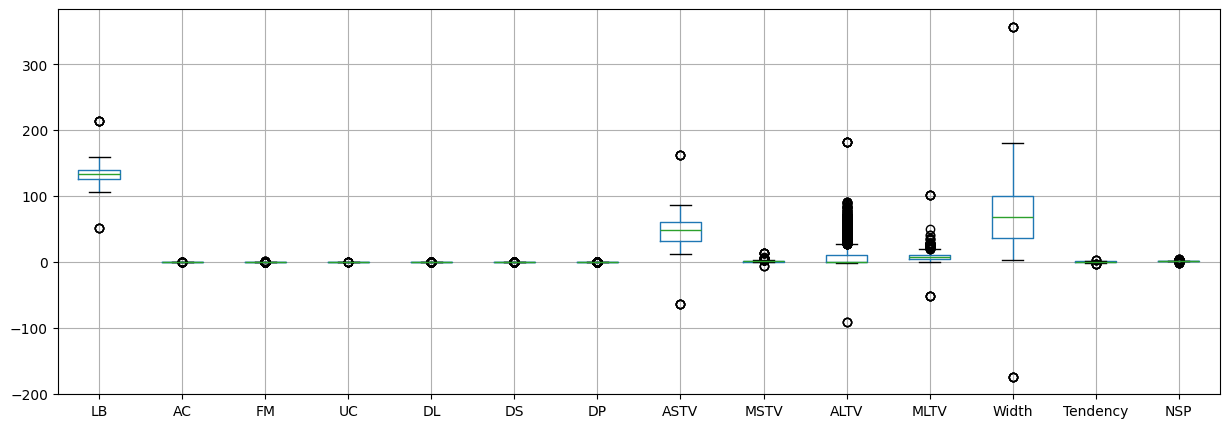

In [ ]:
##checkinng for outliers
df.boxplot(figsize=(15,5))
plt.show()

In [ ]:
# Outlier Capping using IQR Method

def outlier_capping(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].apply(
        lambda x: lower_bound if x < lower_bound
        else upper_bound if x > upper_bound
        else x
    )

for col in df.select_dtypes(include=['int64', 'float64']).columns:
    outlier_capping(df, col)

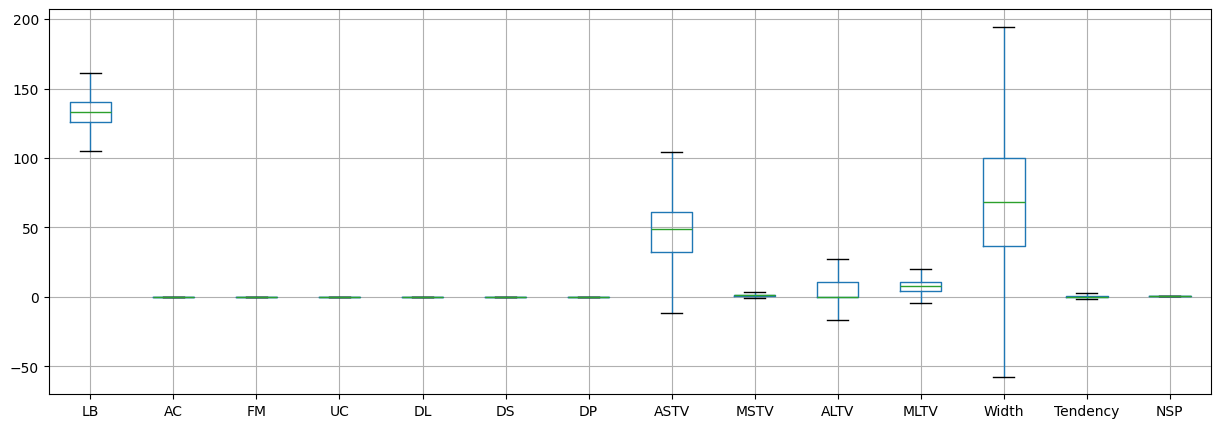

In [ ]:
df.boxplot(figsize=(15,5))
plt.show()

**2. Statistical Summary**

In [ ]:
##Generating Statistical Summary
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.0,2126.0,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.0
mean,133.293725,0.003147,0.001568,0.004362,0.001770,0.0,0.0,46.981873,1.304644,6.691678,8.016212,70.321076,0.319662,1.0
std,9.930227,0.003826,0.002485,0.003001,0.002668,0.0,0.0,17.612745,0.781091,10.378400,5.046784,39.570633,0.621602,0.0
min,105.000000,-0.008409,-0.003850,-0.005177,-0.004934,0.0,0.0,-11.500000,-0.800000,-16.500000,-4.700000,-57.500000,-1.500000,1.0
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.0,0.0,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.0
50%,133.000000,0.001668,0.000000,0.004484,0.000000,0.0,0.0,49.000000,1.200000,0.000000,7.500000,68.000000,0.000000,1.0
75%,140.000000,0.005606,0.002567,0.006536,0.003289,0.0,0.0,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.0
max,161.000000,0.014015,0.006416,0.013564,0.008224,0.0,0.0,104.500000,3.200000,27.500000,20.100000,194.500000,2.500000,1.0


In [ ]:
##Calculating Mean and Median
print("Mean")
print(df.mean(numeric_only=True))

print("\nMedian")
print(df.median(numeric_only=True))

Mean
LB          133.293725
AC            0.003147
FM            0.001568
UC            0.004362
DL            0.001770
DS            0.000000
DP            0.000000
ASTV         46.981873
MSTV          1.304644
ALTV          6.691678
MLTV          8.016212
Width        70.321076
Tendency      0.319662
NSP           1.000000
dtype: float64

Median
LB          133.000000
AC            0.001668
FM            0.000000
UC            0.004484
DL            0.000000
DS            0.000000
DP            0.000000
ASTV         49.000000
MSTV          1.200000
ALTV          0.000000
MLTV          7.500000
Width        68.000000
Tendency      0.000000
NSP           1.000000
dtype: float64


In [ ]:
##calculating standard deviation
print(df.std(numeric_only=True))

LB           9.930227
AC           0.003826
FM           0.002485
UC           0.003001
DL           0.002668
DS           0.000000
DP           0.000000
ASTV        17.612745
MSTV         0.781091
ALTV        10.378400
MLTV         5.046784
Width       39.570633
Tendency     0.621602
NSP          0.000000
dtype: float64


In [ ]:
##Calculating Interquartile Range (IQR)
Q1 = df.quantile(0.25, numeric_only=True)
Q3 = df.quantile(0.75, numeric_only=True)
IQR = Q3 - Q1
print(IQR)

LB          14.000000
AC           0.005606
FM           0.002567
UC           0.004685
DL           0.003289
DS           0.000000
DP           0.000000
ASTV        29.000000
MSTV         1.000000
ALTV        11.000000
MLTV         6.200000
Width       63.000000
Tendency     1.000000
NSP          0.000000
dtype: float64


**3. Data Visualization**

*The statistical summary provides information about the central tendency and variability of the dataset. Variables with higher standard deviation and IQR show greater dispersion among observations.*

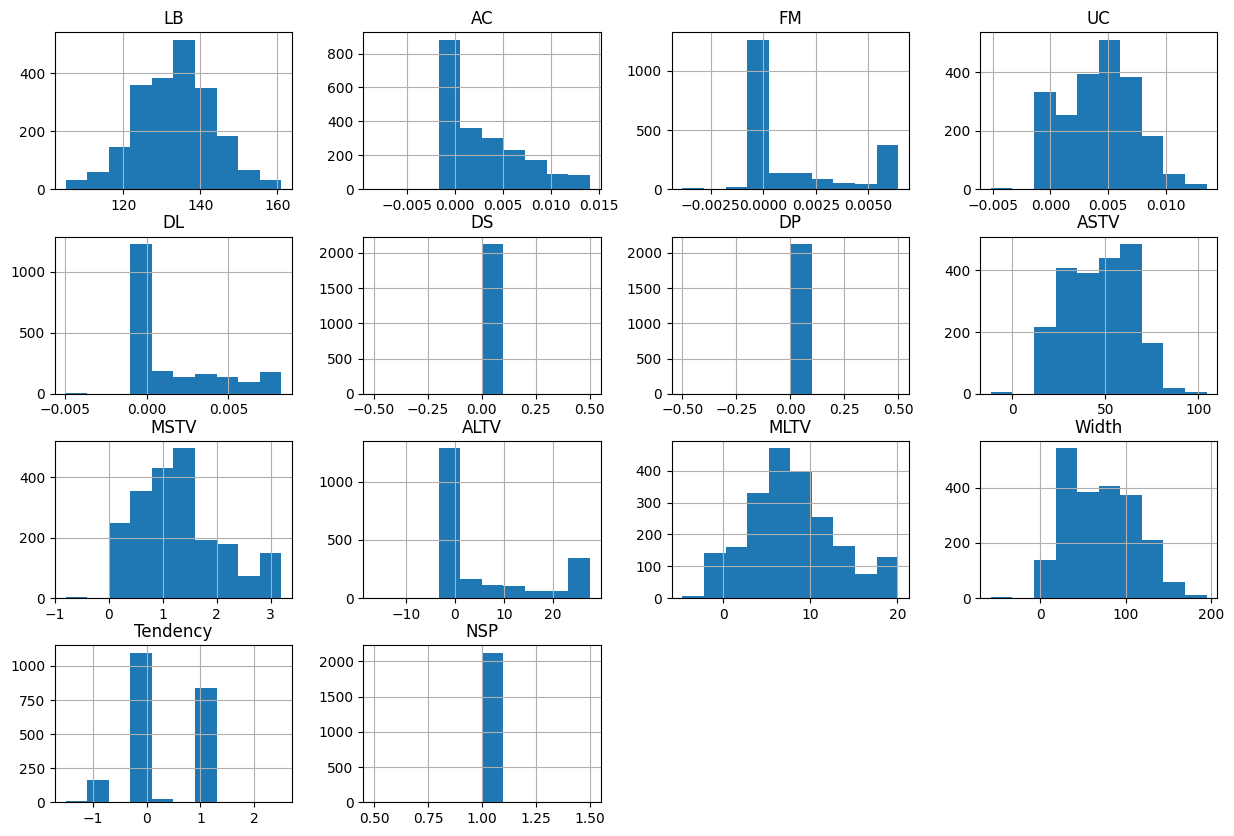

In [ ]:
##Creating Histograms
df.hist(figsize=(15,10))
plt.show()

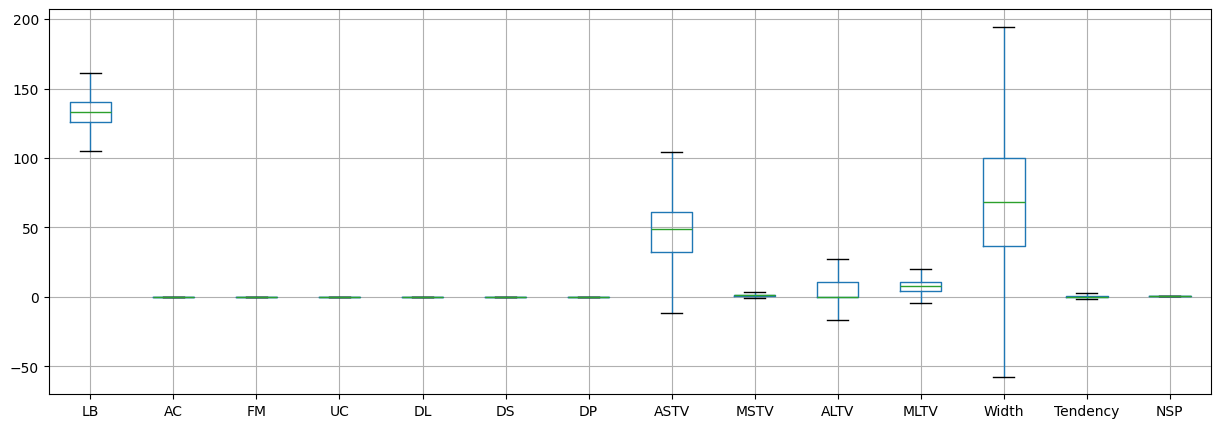

In [ ]:
##creating boxplot
df.boxplot(figsize=(15,5))
plt.show()

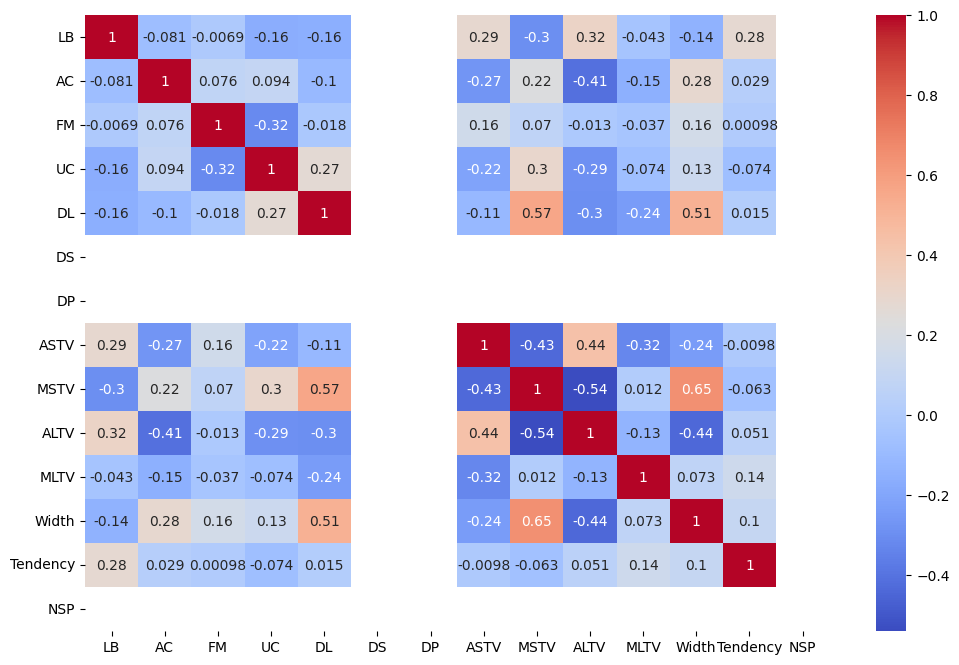

In [ ]:
##creating correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

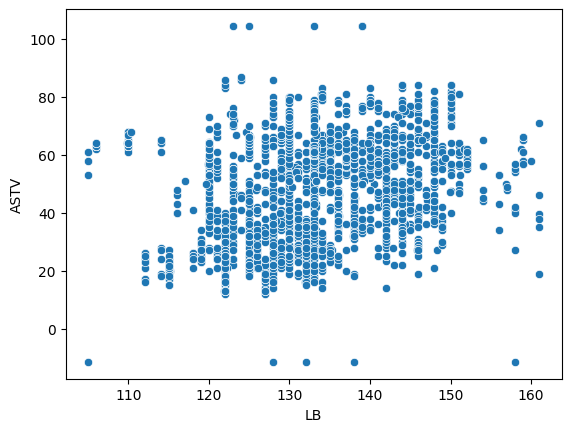

In [ ]:
##creating scatter plot
sns.scatterplot(x='LB', y='ASTV', data=df)
plt.show()

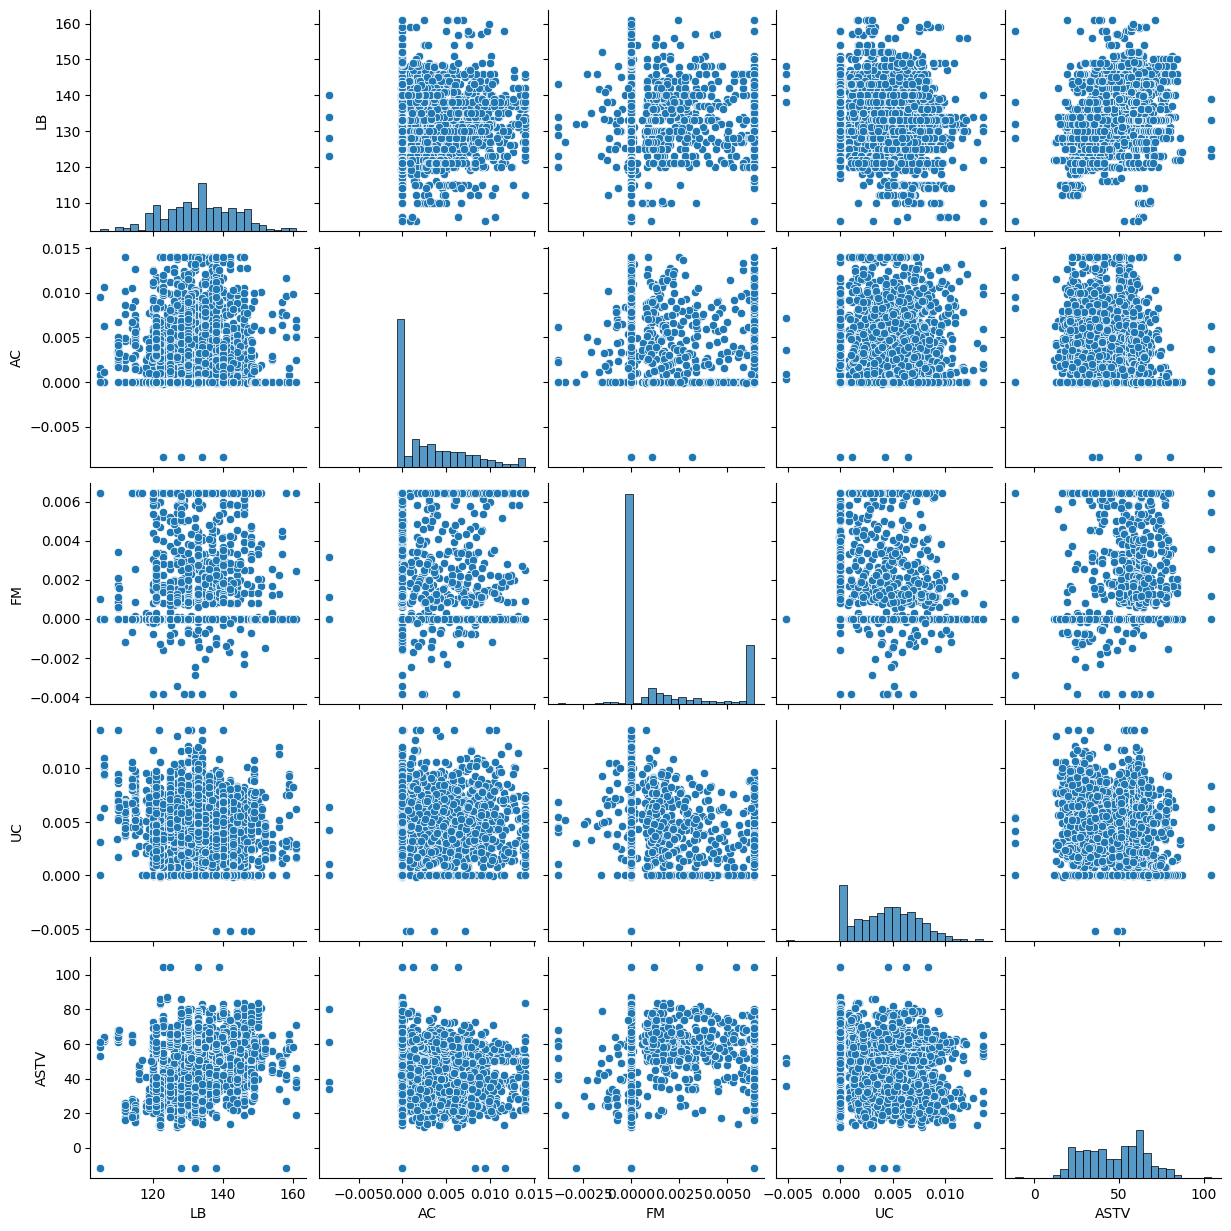

In [ ]:
##creating pair plot
sns.pairplot(df[['LB','AC','FM','UC','ASTV']])
plt.show()

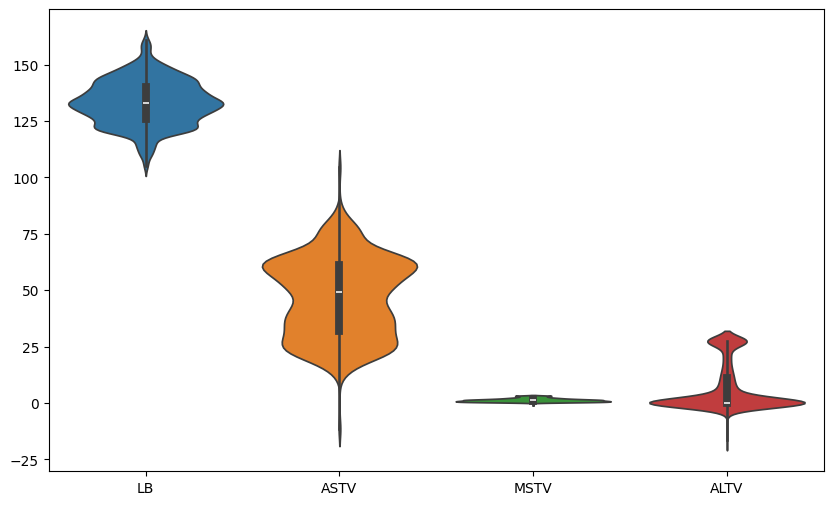

In [ ]:
##creating violin plot
plt.figure(figsize=(10,6))
sns.violinplot(data=df[['LB','ASTV','MSTV','ALTV']])
plt.show()

**4.	Pattern Recognition and Insights:**

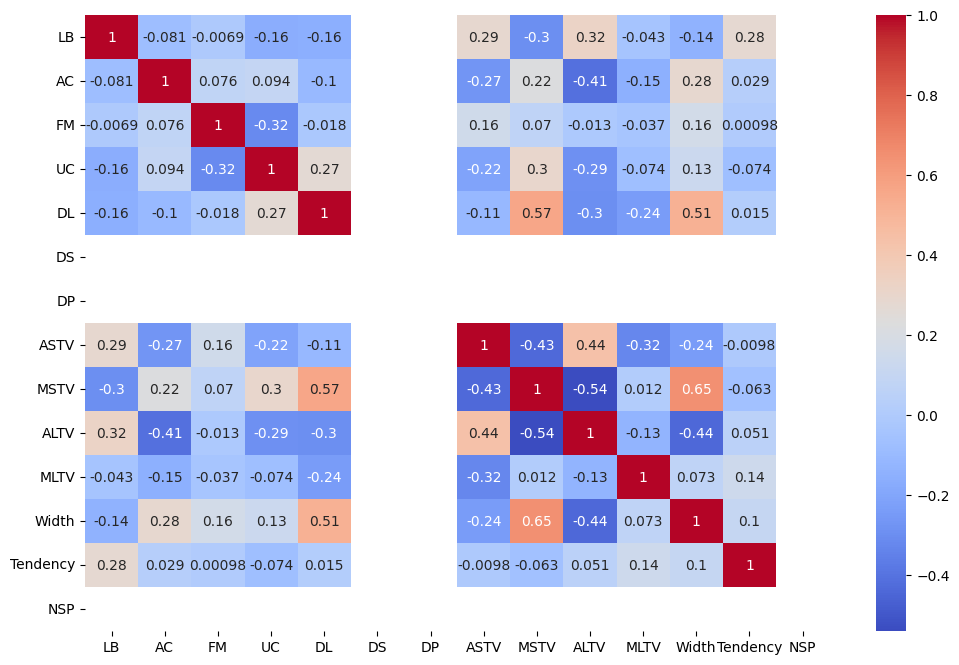

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

*Insights : The correlation analysis shows moderate positive relationships between variables such as MSTV and Width, ASTV and NSP, and DL with MSTV. Negative correlations are observed between AC and NSP, and ALTV and Width. These relationships indicate that changes in fetal heart rate variability measures may be associated with fetal health indicators.*

**5.	Conclusion:**

The cardiotocographic dataset was analyzed using statistical methods and visualizations to better understand the data. The analysis helped identify the distribution of different variables, detect outliers, and explore relationships between fetal health indicators. Correlation analysis showed that some variables are related and may influence each other.

Overall, the dataset provided useful insights into fetal heart rate patterns and variability measures. These findings can support further analysis and the development of predictive models that may help in assessing fetal health more effectively.